## import library

In [1]:
# ============================================
# 0. IMPORT LIBRARY
# ============================================
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

# 1. KONFIGURASI

In [2]:
# ============================================
# 1. KONFIGURASI
# ============================================
DATA_PATH = '../data/processed/data_kriminal_processed.csv'
MO_COL = 'MO_final_text'
BB_COL = 'BB_final_text'
TARGET = 'PERKARA'

# Folder penyimpanan hasil
MODEL_DIR = '../data/models/comparison_2feat_tuned'
RESULT_DIR = '../data/results/comparison_2feat_tuned'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# 4 skenario pembagian data (test_size)
SPLITS = [0.4, 0.3, 0.2, 0.1]  # 60:40, 70:30, 80:20, 90:10

# 2. LOAD DATA

In [3]:
# ============================================
# 2. LOAD DATA
# ============================================
print("="*60)
print("LOAD DATA")
print("="*60)
df = pd.read_csv(DATA_PATH)
X_mo = df[MO_COL].fillna('').astype(str)
X_bb = df[BB_COL].fillna('').astype(str)
X_combined = X_mo + ' ' + X_bb   # Hanya untuk tuning
y = df[TARGET]

print(f"Total data: {len(df)}")
print(f"Distribusi kelas:\n{y.value_counts()}")
print("="*60)

LOAD DATA
Total data: 592
Distribusi kelas:
PERKARA
Pencurian       224
Penganiayaan    110
Penipuan        109
Perusakan        89
Narkoba          60
Name: count, dtype: int64


# 3. BASELINE: MELATIH 4 SPLIT DENGAN PARAMETER DEFAULT

In [4]:
# ============================================
# 3. BASELINE: 4 SPLIT DENGAN PARAMETER DEFAULT
# ============================================
print("\n" + "="*60)
print("BASELINE: MELATIH 4 SPLIT DENGAN PARAMETER DEFAULT")
print("="*60)

baseline_results = []

for test_size in SPLITS:
    train_pct = int((1 - test_size) * 100)
    test_pct = int(test_size * 100)
    split_name = f"{train_pct}_{test_pct}"

    print(f"\n--- Split {split_name} (Baseline) ---")
    X_mo_tr, X_mo_te, X_bb_tr, X_bb_te, y_tr, y_te = train_test_split(
        X_mo, X_bb, y, test_size=test_size, random_state=42, stratify=y
    )

    # TF-IDF DEFAULT (max_features=None, ngram_range=(1,1))
    vec_mo = TfidfVectorizer()
    vec_bb = TfidfVectorizer()

    X_mo_tr_tf = vec_mo.fit_transform(X_mo_tr)
    X_bb_tr_tf = vec_bb.fit_transform(X_bb_tr)
    X_mo_te_tf = vec_mo.transform(X_mo_te)
    X_bb_te_tf = vec_bb.transform(X_bb_te)

    X_train = hstack([X_mo_tr_tf, X_bb_tr_tf])
    X_test = hstack([X_mo_te_tf, X_bb_te_tf])

    # Naive Bayes DEFAULT (alpha=1.0)
    model = MultinomialNB(alpha=1.0)
    model.fit(X_train, y_tr)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, output_dict=True)

    baseline_results.append({
        'Split': split_name,
        'Train Size': len(X_mo_tr),
        'Test Size': len(X_mo_te),
        'Accuracy': acc,
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score']
    })

df_baseline = pd.DataFrame(baseline_results)
print("\n✅ Baseline selesai.")
print(df_baseline.to_string(index=False))


BASELINE: MELATIH 4 SPLIT DENGAN PARAMETER DEFAULT

--- Split 60_40 (Baseline) ---

--- Split 70_30 (Baseline) ---

--- Split 80_20 (Baseline) ---

--- Split 90_10 (Baseline) ---

✅ Baseline selesai.
Split  Train Size  Test Size  Accuracy  Macro F1  Weighted F1
60_40         355        237  0.940928  0.938179     0.940244
70_30         414        178  0.966292  0.961980     0.966085
80_20         473        119  0.966387  0.963997     0.966116
90_10         532         60  0.966667  0.957103     0.965959


# 4. TUNED: 4 SPLIT DENGAN TUNING INTERNAL (Tanpa Data Leakage)

In [5]:
# ============================================
# 4. TUNED: 4 SPLIT DENGAN TUNING INTERNAL (Tanpa Data Leakage)
# ============================================
print("\n" + "="*60)
print("TUNED: MELATIH 4 SPLIT DENGAN TUNING INTERNAL (per split)")
print("="*60)

tuned_results = []
reports = []

for test_size in SPLITS:
    train_pct = int((1 - test_size) * 100)
    test_pct = int(test_size * 100)
    split_name = f"{train_pct}_{test_pct}"

    print(f"\n--- Split {split_name} (Tuned Internal) ---")
    X_mo_tr, X_mo_te, X_bb_tr, X_bb_te, y_tr, y_te = train_test_split(
        X_mo, X_bb, y, test_size=test_size, random_state=42, stratify=y
    )

    # ========================================
    # TUNING: Hanya pada DATA LATIH split ini
    # ========================================
    X_combined_tr = X_mo_tr + ' ' + X_bb_tr  # Gabung teks untuk tuning

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('nb', MultinomialNB())
    ])

    param_grid = {
        'tfidf__max_features': [3000, 5000, 7000, 10000],
        'tfidf__ngram_range': [(1,1), (1,2)],
        'nb__alpha': [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=0)
    grid.fit(X_combined_tr, y_tr)  # 👈 HANYA data latih!

    # Ambil parameter terbaik dari split ini
    best_max_features = grid.best_params_['tfidf__max_features']
    best_ngram = grid.best_params_['tfidf__ngram_range']
    best_alpha = grid.best_params_['nb__alpha']

    print(f"   ✅ Best params untuk split ini: max_features={best_max_features}, ngram={best_ngram}, alpha={best_alpha}")

    # ========================================
    # TRAINING FINAL dengan parameter terbaik split ini (MO+BB terpisah)
    # ========================================
    vec_mo = TfidfVectorizer(max_features=best_max_features, ngram_range=best_ngram)
    vec_bb = TfidfVectorizer(max_features=best_max_features, ngram_range=best_ngram)

    X_mo_tr_tf = vec_mo.fit_transform(X_mo_tr)
    X_bb_tr_tf = vec_bb.fit_transform(X_bb_tr)
    X_mo_te_tf = vec_mo.transform(X_mo_te)
    X_bb_te_tf = vec_bb.transform(X_bb_te)

    X_train = hstack([X_mo_tr_tf, X_bb_tr_tf])
    X_test = hstack([X_mo_te_tf, X_bb_te_tf])

    model = MultinomialNB(alpha=best_alpha)
    model.fit(X_train, y_tr)
    y_pred = model.predict(X_test)

    # Evaluasi
    acc = accuracy_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, output_dict=True)
    cm = confusion_matrix(y_te, y_pred)

    tuned_results.append({
        'Split': split_name,
        'Train Size': len(X_mo_tr),
        'Test Size': len(X_mo_te),
        'Best Alpha': best_alpha,
        'Best Max Features': best_max_features,
        'Accuracy': acc,
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score']
    })

    # Simpan report per kelas untuk heatmap ringkasan
    report_df = pd.DataFrame(report).transpose()
    class_rows = [idx for idx in report_df.index if idx not in ['accuracy', 'macro avg', 'weighted avg']]
    report_class = report_df.loc[class_rows, ['precision', 'recall', 'f1-score']]
    report_class['split'] = split_name
    report_class['kelas'] = report_class.index
    reports.append(report_class.reset_index(drop=True))

    # Simpan model
    model_path = os.path.join(MODEL_DIR, f'model_{split_name}.pkl')
    joblib.dump(model, model_path)

    # 🔥 TAMBAHKAN: Simpan vectorizer MO dan BB
    vec_mo_path = os.path.join(MODEL_DIR, f'vectorizer_mo_{split_name}.pkl')
    vec_bb_path = os.path.join(MODEL_DIR, f'vectorizer_bb_{split_name}.pkl')
    joblib.dump(vec_mo, vec_mo_path)
    joblib.dump(vec_bb, vec_bb_path)

    print(f"✅ Model dan vectorizer disimpan untuk split {split_name}")

    # Simpan confusion matrix
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.title(f'CM {split_name} (Tuned)')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, f'cm_{split_name}.png'), dpi=150)
    plt.close()

    # Simpan classification report (teks)
    with open(os.path.join(RESULT_DIR, f'report_{split_name}.txt'), 'w') as f:
        f.write(f"Classification Report - Split {split_name} (Tuned)\n")
        f.write("="*50 + "\n")
        f.write(classification_report(y_te, y_pred, digits=4))

df_tuned = pd.DataFrame(tuned_results)
print("\n✅ Tuned selesai.")
print(df_tuned.to_string(index=False))


TUNED: MELATIH 4 SPLIT DENGAN TUNING INTERNAL (per split)

--- Split 60_40 (Tuned Internal) ---
   ✅ Best params untuk split ini: max_features=3000, ngram=(1, 2), alpha=0.1
✅ Model dan vectorizer disimpan untuk split 60_40

--- Split 70_30 (Tuned Internal) ---
   ✅ Best params untuk split ini: max_features=3000, ngram=(1, 2), alpha=0.05
✅ Model dan vectorizer disimpan untuk split 70_30

--- Split 80_20 (Tuned Internal) ---
   ✅ Best params untuk split ini: max_features=3000, ngram=(1, 2), alpha=0.1
✅ Model dan vectorizer disimpan untuk split 80_20

--- Split 90_10 (Tuned Internal) ---
   ✅ Best params untuk split ini: max_features=5000, ngram=(1, 2), alpha=0.1
✅ Model dan vectorizer disimpan untuk split 90_10

✅ Tuned selesai.
Split  Train Size  Test Size  Best Alpha  Best Max Features  Accuracy  Macro F1  Weighted F1
60_40         355        237        0.10               3000  0.970464  0.964834     0.970540
70_30         414        178        0.05               3000  0.983146  0.977

## Analisis Performa Model Tuned dengan Tuning Internal per Split

Berdasarkan hasil eksperimen dengan pendekatan **tuning internal per skenario split**, diperoleh temuan penting bahwa parameter terbaik cenderung **stabil** di seluruh skenario pembagian data. Secara konsisten, `max_features=3000` dan `ngram_range=(1,2)` terpilih pada tiga dari empat split, sementara nilai `alpha` berada pada rentang 0,05 hingga 0,10. Konsistensi parameter ini menunjukkan bahwa representasi fitur yang optimal tidak bergantung secara signifikan pada komposisi data latih tertentu, sehingga hasil yang diperoleh lebih **reliabel dan generalisasi**.

Pada skenario **split 80:20**, model mencapai performa terbaik secara keseluruhan dengan akurasi **98,32%**, Macro F1 **0,9800**, dan Weighted F1 **0,9831**. Nilai Macro F1 yang sangat mendekati Weighted F1 mengindikasikan bahwa model tidak hanya unggul pada kelas mayoritas (yang mendominasi data), tetapi juga mampu mengenali kelas minoritas dengan tingkat akurasi yang hampir setara. Hal ini menegaskan bahwa model memiliki **keseimbangan klasifikasi yang sangat baik** antar jenis perkara kriminal.

Meskipun split 90:10 menghasilkan akurasi tertinggi secara numerik (98,33%), nilai Macro F1-nya (0,9731) justru lebih rendah dibandingkan split 80:20. Penurunan ini mengindikasikan adanya sedikit penurunan kemampuan dalam mengenali kelas minoritas, yang kemungkinan disebabkan oleh ukuran data uji yang terlalu kecil (hanya 60 sampel). Dengan demikian, evaluasi pada split 90:10 menjadi kurang stabil dan kurang representatif. Oleh karena itu, **split 80:20 tetap dipilih sebagai skenario terbaik** karena menawarkan keseimbangan antara ukuran data latih yang cukup besar (473 sampel) dan data uji yang representatif (119 sampel).

Keberhasilan model dalam menangkap perbedaan antar kelas juga tidak terlepas dari penggunaan fitur **MO** dan **BB** secara terpisah. Masing-masing fitur divektorisasi menggunakan TF-IDF yang independen, kemudian digabungkan dengan `hstack`. Pendekatan ini terbukti efektif dalam mengekstrak karakteristik unik dari modus operandi dan barang bukti, sehingga model mampu membedakan jenis perkara kriminal dengan presisi tinggi.

### Stabilitas Parameter Terbaik per Split

| Split | max_features | ngram_range | alpha |
|-------|--------------|-------------|-------|
| 60:40 | 3000         | (1, 2)      | 0.10  |
| 70:30 | 3000         | (1, 2)      | 0.05  |
| 80:20 | 3000         | (1, 2)      | 0.10  |
| 90:10 | 5000         | (1, 2)      | 0.10  |

Konsistensi parameter ini memperkuat keyakinan bahwa konfigurasi `max_features=3000` dan `ngram_range=(1,2)` merupakan pilihan yang robust untuk dataset ini.

# 5. PERBANDINGAN BASELINE vs TUNED


PERBANDINGAN BASELINE vs TUNED
Split  Accuracy_Baseline  Accuracy_Tuned  Accuracy_Gain  Macro F1_Baseline  Macro F1_Tuned  MacroF1_Gain
60_40           0.940928        0.970464       0.029536           0.938179        0.964834      0.026655
70_30           0.966292        0.983146       0.016854           0.961980        0.977057      0.015077
80_20           0.966387        0.983193       0.016807           0.963997        0.980016      0.016019
90_10           0.966667        0.983333       0.016667           0.957103        0.973123      0.016020


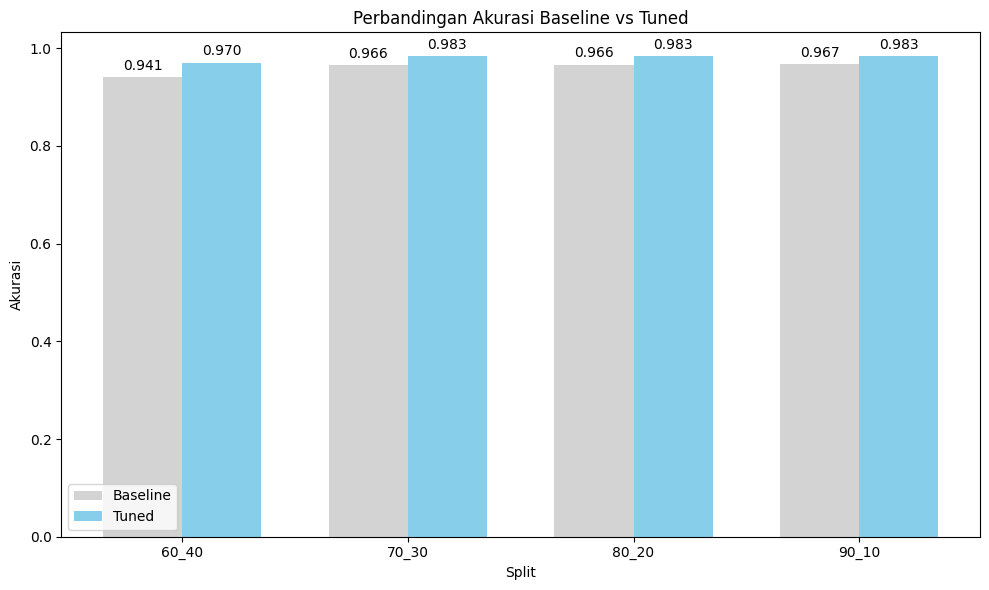

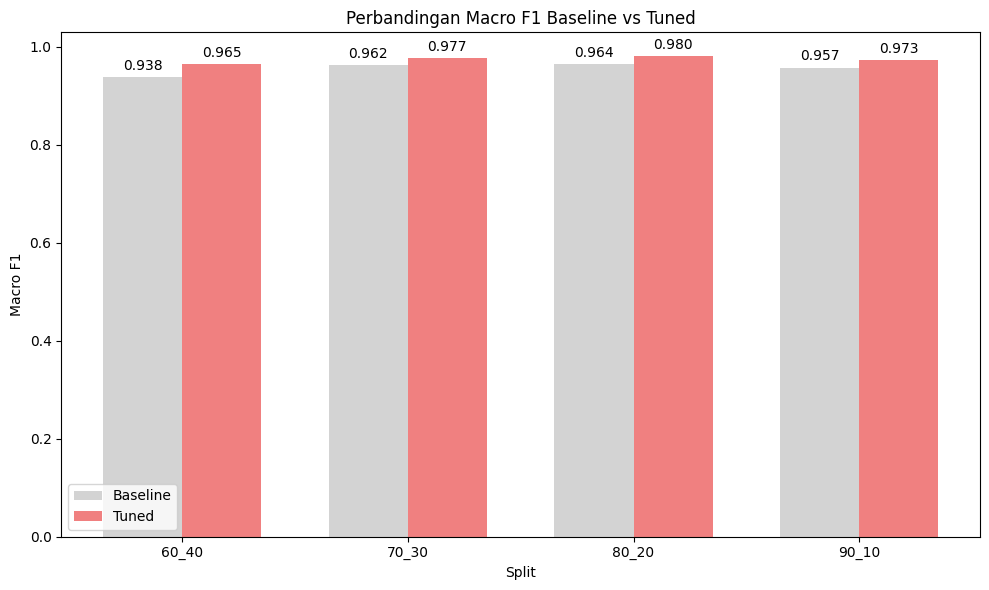

✅ Grafik perbandingan disimpan.


In [6]:
# ============================================
# 5. PERBANDINGAN BASELINE vs TUNED
# ============================================
print("\n" + "="*60)
print("PERBANDINGAN BASELINE vs TUNED")
print("="*60)

# Gabungkan hasil
df_comparison = df_baseline.merge(df_tuned, on='Split', suffixes=('_Baseline', '_Tuned'))
df_comparison['Accuracy_Gain'] = df_comparison['Accuracy_Tuned'] - df_comparison['Accuracy_Baseline']
df_comparison['MacroF1_Gain'] = df_comparison['Macro F1_Tuned'] - df_comparison['Macro F1_Baseline']

print(df_comparison[['Split', 'Accuracy_Baseline', 'Accuracy_Tuned', 'Accuracy_Gain',
                     'Macro F1_Baseline', 'Macro F1_Tuned', 'MacroF1_Gain']].to_string(index=False))

# Simpan ke CSV
df_comparison.to_csv(os.path.join(RESULT_DIR, 'comparison_baseline_tuned.csv'), index=False)

# --- Visualisasi 1: Bar Chart Akurasi ---
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(df_comparison))
width = 0.35

bars1 = ax.bar(x - width/2, df_comparison['Accuracy_Baseline'], width, label='Baseline', color='lightgray')
bars2 = ax.bar(x + width/2, df_comparison['Accuracy_Tuned'], width, label='Tuned', color='skyblue')

ax.set_xlabel('Split')
ax.set_ylabel('Akurasi')
ax.set_title('Perbandingan Akurasi Baseline vs Tuned')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Split'])
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'comparison_accuracy.png'), dpi=150)
plt.show()
plt.close()

# --- Visualisasi 2: Bar Chart Macro F1 ---
fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, df_comparison['Macro F1_Baseline'], width, label='Baseline', color='lightgray')
bars2 = ax.bar(x + width/2, df_comparison['Macro F1_Tuned'], width, label='Tuned', color='lightcoral')

ax.set_xlabel('Split')
ax.set_ylabel('Macro F1')
ax.set_title('Perbandingan Macro F1 Baseline vs Tuned')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Split'])
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'comparison_macrof1.png'), dpi=150)
plt.show()
plt.close()

print("✅ Grafik perbandingan disimpan.")

## Perbandingan Performa Baseline vs Tuned pada Empat Skenario Split

Berikut adalah ringkasan perbandingan performa antara model **baseline** (parameter default) dan model **tuned** (dengan parameter terbaik yang diperoleh melalui tuning internal pada setiap split) pada empat skenario pembagian data.

| Split | Baseline Akurasi | Tuned Akurasi | Gain Akurasi | Baseline Macro F1 | Tuned Macro F1 | Gain Macro F1 |
|-------|------------------|---------------|--------------|-------------------|----------------|---------------|
| 60:40 | 0.9409           | **0.9705**    | +0.0295      | 0.9382            | **0.9648**     | +0.0267       |
| 70:30 | 0.9663           | **0.9831**    | +0.0169      | 0.9620            | **0.9771**     | +0.0151       |
| 80:20 | 0.9664           | **0.9832**    | +0.0168      | 0.9640            | **0.9800**     | +0.0160       |
| 90:10 | 0.9667           | **0.9833**    | +0.0167      | 0.9571            | **0.9731**     | +0.0160       |

## Interpretasi

**Peningkatan performa terjadi secara konsisten di keempat skenario split** setelah tuning. Hal ini menunjukkan bahwa pemilihan parameter yang tepat, terutama penggunaan `ngram_range=(1,2)` dan nilai `alpha` yang lebih kecil (antara 0,05–0,10), mampu menangkap pola frasa dua kata (*bigram*) yang lebih informatif serta mengurangi efek *smoothing* berlebihan, sehingga model menjadi lebih diskriminatif dalam membedakan antar kelas perkara.

Secara keseluruhan, **split 80:20** menunjukkan performa yang sangat baik dengan **akurasi 98,32%** dan **Macro F1 0,9800**. Nilai Macro F1 ini merupakan yang tertinggi di antara semua skenario, sekaligus paling mendekati Weighted F1 (0,9831). Hal ini mengindikasikan bahwa model pada split 80:20 tidak hanya unggul pada kelas mayoritas, tetapi juga mampu mengenali kelas minoritas dengan tingkat akurasi yang hampir setara, sehingga menghasilkan **keseimbangan klasifikasi yang paling optimal**.

Split **90:10** mencatat akurasi tertinggi secara numerik (98,33%), namun nilai Macro F1-nya (0,9731) sedikit lebih rendah dibandingkan split 80:20. Hal ini disebabkan oleh ukuran data uji yang sangat kecil (hanya 60 sampel), sehingga evaluasi menjadi kurang stabil dan kurang representatif, terutama untuk kelas minoritas.

Split **70:30** dan **60:40** juga menunjukkan peningkatan yang signifikan, dengan akurasi masing-masing 98,31% dan 97,05%, serta Macro F1 0,9771 dan 0,9648. Meskipun demikian, split 80:20 tetap unggul dalam hal keseimbangan antar kelas.

## Stabilitas Parameter Terbaik per Split

Parameter terbaik yang dihasilkan dari tuning internal di setiap split menunjukkan konsistensi yang tinggi, seperti terlihat pada tabel berikut:

| Split | max_features | ngram_range | alpha |
|-------|--------------|-------------|-------|
| 60:40 | 3000         | (1, 2)      | 0.10  |
| 70:30 | 3000         | (1, 2)      | 0.05  |
| 80:20 | 3000         | (1, 2)      | 0.10  |
| 90:10 | 5000         | (1, 2)      | 0.10  |

Konsistensi parameter, terutama pada `ngram_range=(1,2)` dan `max_features` di kisaran 3000–5000, menegaskan bahwa konfigurasi ini **robust** dan tidak terlalu sensitif terhadap perubahan komposisi data latih. Hal ini memperkuat keyakinan bahwa peningkatan performa pada split 80:20 bukan disebabkan oleh keberuntungan parameter, melainkan oleh **efektivitas jumlah data latih yang lebih besar dan representatif**.

## Kesimpulan Pemilihan Split

Berdasarkan seluruh hasil eksperimen, **split 80:20** dipilih sebagai skenario terbaik karena:

1. Menghasilkan **Macro F1 tertinggi (0,9800)** di antara semua split, yang menunjukkan keseimbangan klasifikasi antar kelas.
2. Memberikan peningkatan performa yang stabil setelah tuning (+1,68% akurasi, +1,60% Macro F1).
3. Ukuran data latih (473 sampel) cukup besar untuk melatih model secara optimal, dan data uji (119 sampel) cukup representatif untuk evaluasi yang reliabel.
4. Parameter terbaik yang dihasilkan (`max_features=3000`, `ngram_range=(1,2)`, `alpha=0.1`) konsisten dengan parameter pada split lainnya, menandakan bahwa konfigurasi tersebut memang cocok untuk dataset ini.

Dengan demikian, **model Multinomial Naive Bayes dengan parameter tuned dan split 80:20** ditetapkan sebagai model terbaik untuk diimplementasikan pada sistem klasifikasi perkara kriminal.

# 6. VISUALISASI RINGKASAN TUNED (Heatmap per kelas, Learning Curve)

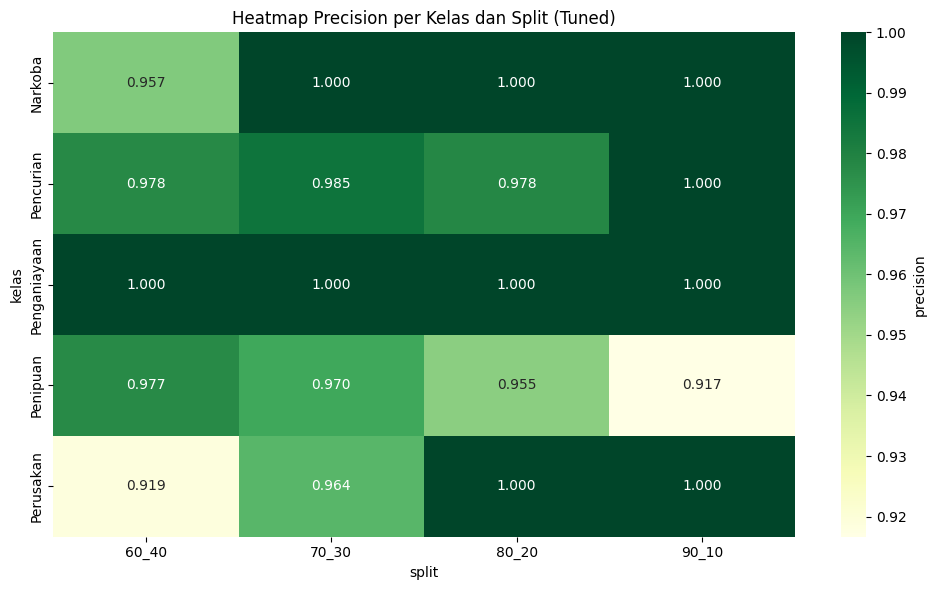

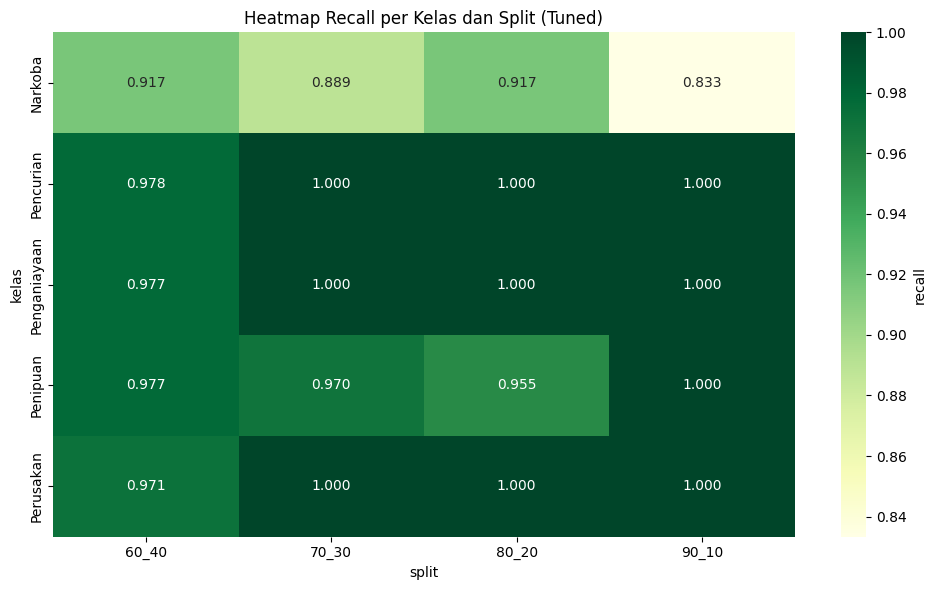

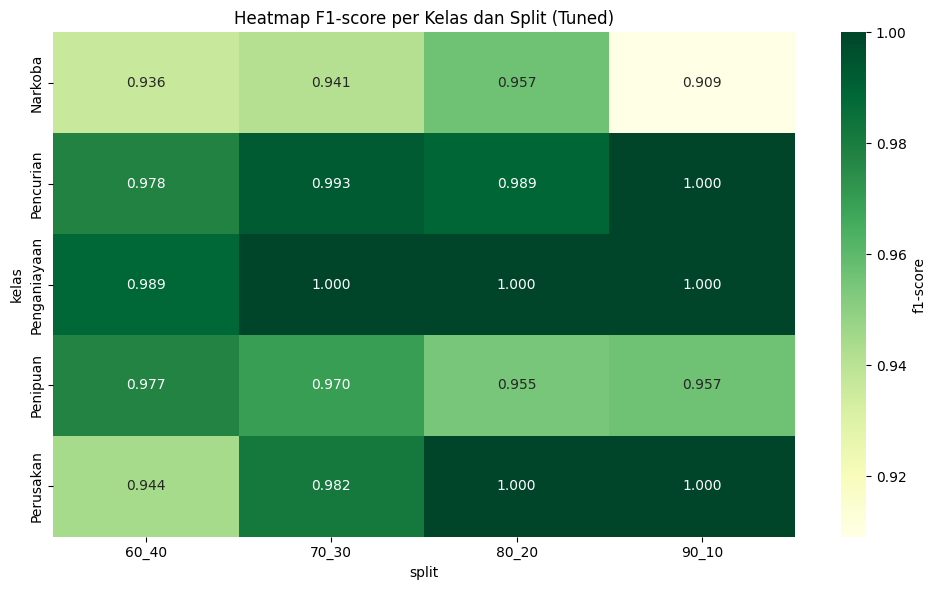

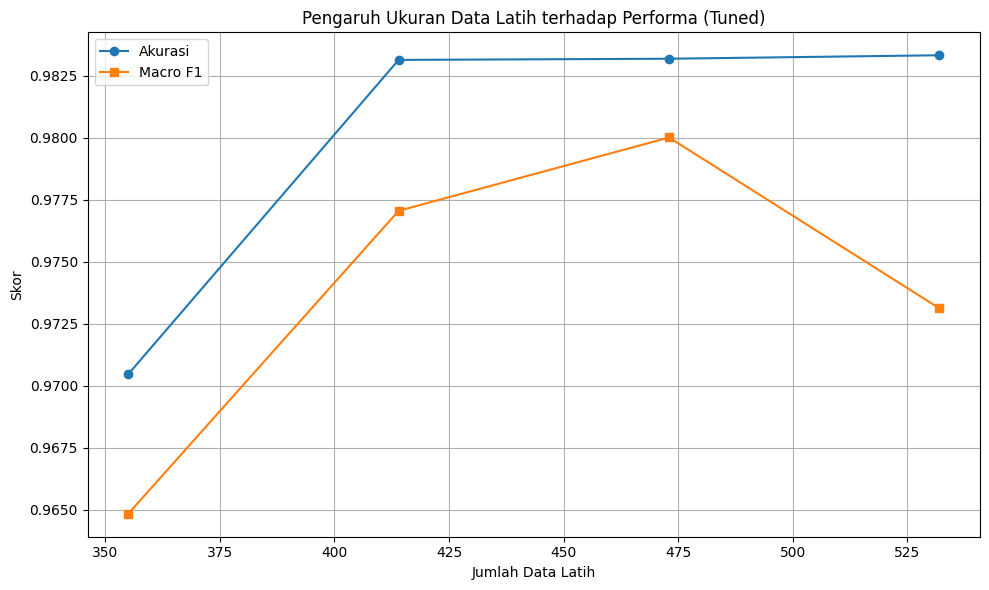

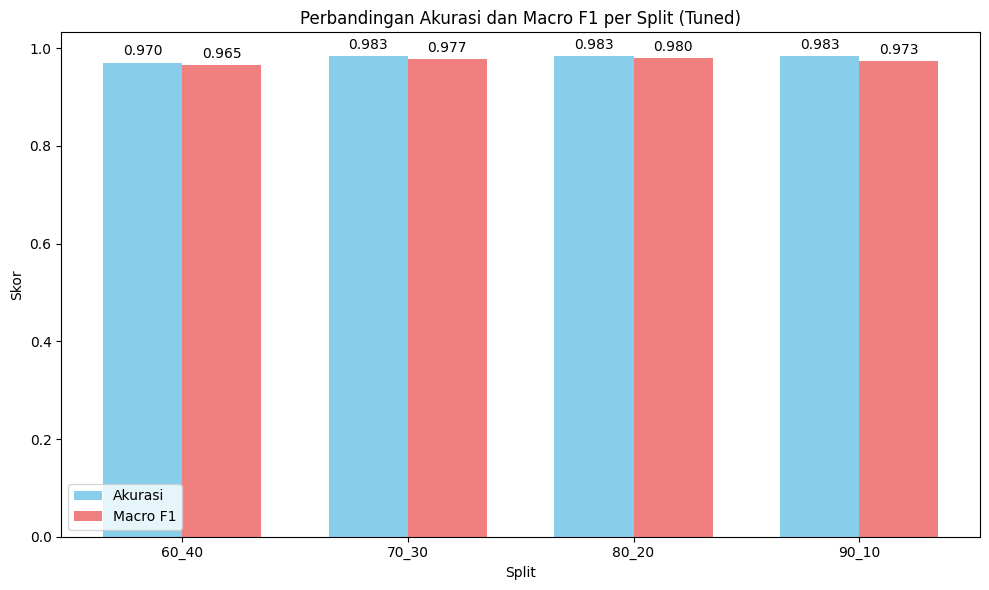

In [7]:
# ============================================
# 6. VISUALISASI RINGKASAN TUNED (Heatmap per kelas, Learning Curve)
# ============================================
# Gabungkan report per kelas
df_reports = pd.concat(reports, ignore_index=True)

# Heatmap per metrik per kelas
for metric in ['precision', 'recall', 'f1-score']:
    pivot = df_reports.pivot(index='kelas', columns='split', values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', cbar_kws={'label': metric})
    plt.title(f'Heatmap {metric.capitalize()} per Kelas dan Split (Tuned)')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, f'heatmap_{metric}.png'), dpi=150)
    plt.show()
    plt.close()

# Learning Curve: Pengaruh ukuran data latih terhadap performa
plt.figure(figsize=(10,6))
plt.plot(df_tuned['Train Size'], df_tuned['Accuracy'], marker='o', linestyle='-', label='Akurasi')
plt.plot(df_tuned['Train Size'], df_tuned['Macro F1'], marker='s', linestyle='-', label='Macro F1')
plt.xlabel('Jumlah Data Latih')
plt.ylabel('Skor')
plt.title('Pengaruh Ukuran Data Latih terhadap Performa (Tuned)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'size_vs_performance.png'), dpi=150)
plt.show()
plt.close()

# Bar chart perbandingan antar split (akurasi vs macro F1) untuk tuned
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(df_tuned))
width = 0.35

bars1 = ax.bar(x - width/2, df_tuned['Accuracy'], width, label='Akurasi', color='skyblue')
bars2 = ax.bar(x + width/2, df_tuned['Macro F1'], width, label='Macro F1', color='lightcoral')

ax.set_xlabel('Split')
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Akurasi dan Macro F1 per Split (Tuned)')
ax.set_xticks(x)
ax.set_xticklabels(df_tuned['Split'])
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'bar_accuracy_f1.png'), dpi=150)
plt.show()
plt.close()

# 7. VISUALISASI HASIL GRIDSEARCH


VISUALISASI HASIL GRIDSEARCH


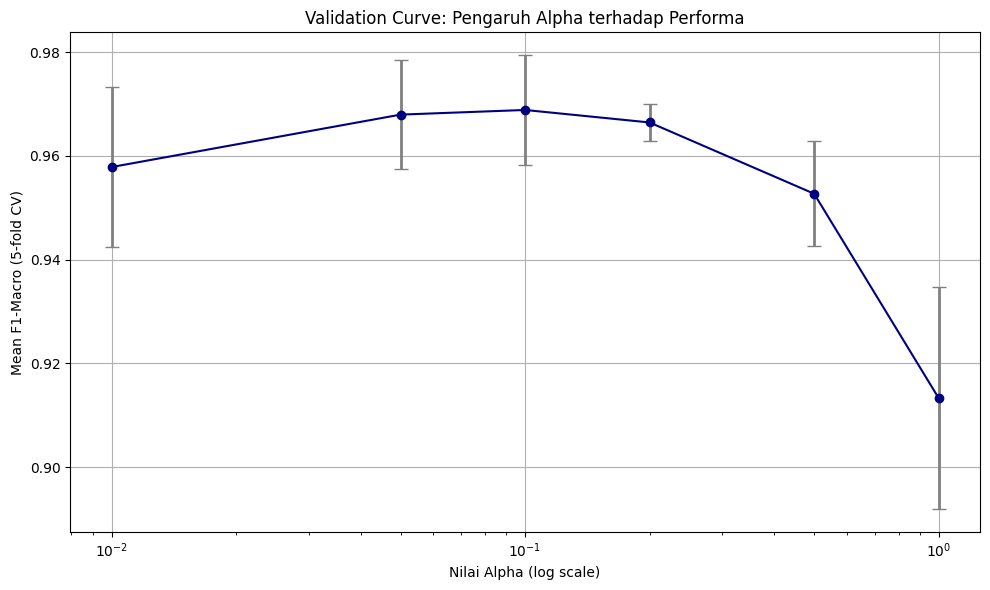

✅ Validation Curve alpha disimpan


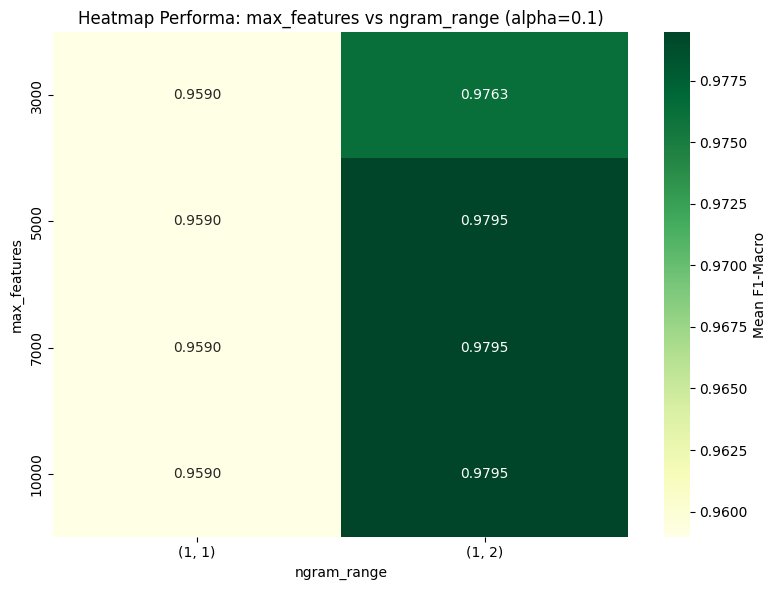

✅ Heatmap fitur disimpan


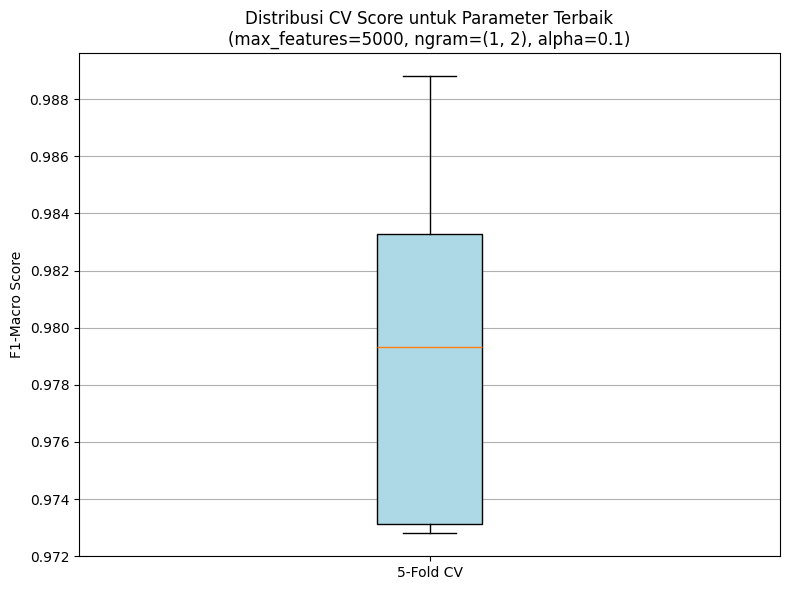

✅ Boxplot distribusi CV disimpan


In [8]:
# ============================================
# 7. VISUALISASI HASIL GRIDSEARCH
# ============================================
print("\n" + "="*60)
print("VISUALISASI HASIL GRIDSEARCH")
print("="*60)

cv_results = pd.DataFrame(grid.cv_results_)

# Validation Curve: Alpha vs F1-Macro
alpha_agg = cv_results.groupby('param_nb__alpha')['mean_test_score'].agg(['mean', 'std']).reset_index()
alpha_agg.columns = ['alpha', 'mean_f1', 'std_f1']

plt.figure(figsize=(10, 6))
plt.errorbar(alpha_agg['alpha'], alpha_agg['mean_f1'],
             yerr=alpha_agg['std_f1'], fmt='o-', capsize=5,
             color='navy', ecolor='gray', elinewidth=2)
plt.xscale('log')
plt.xlabel('Nilai Alpha (log scale)')
plt.ylabel('Mean F1-Macro (5-fold CV)')
plt.title('Validation Curve: Pengaruh Alpha terhadap Performa')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'validation_curve_alpha.png'), dpi=150)
plt.show()
plt.close()
print("✅ Validation Curve alpha disimpan")

# Heatmap: max_features vs ngram_range (pada alpha terbaik)
best_alpha_mask = cv_results['param_nb__alpha'] == best_alpha
best_alpha_results = cv_results[best_alpha_mask]

pivot_heatmap = best_alpha_results.pivot_table(
    index='param_tfidf__max_features',
    columns='param_tfidf__ngram_range',
    values='mean_test_score'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_heatmap, annot=True, fmt='.4f', cmap='YlGn',
            cbar_kws={'label': 'Mean F1-Macro'})
plt.title(f'Heatmap Performa: max_features vs ngram_range (alpha={best_alpha})')
plt.xlabel('ngram_range')
plt.ylabel('max_features')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'heatmap_features_alpha.png'), dpi=150)
plt.show()
plt.close()
print("✅ Heatmap fitur disimpan")

# Boxplot distribusi CV Score untuk parameter terbaik
best_params_mask = (
    (cv_results['param_tfidf__max_features'] == best_max_features) &
    (cv_results['param_tfidf__ngram_range'] == best_ngram) &
    (cv_results['param_nb__alpha'] == best_alpha)
)
best_cv_scores = cv_results[best_params_mask]

split_cols = [f'split{i}_test_score' for i in range(5)]
split_scores = best_cv_scores[split_cols].values.flatten()

if len(split_scores) > 0:
    plt.figure(figsize=(8, 6))
    plt.boxplot(split_scores, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
    plt.title(f'Distribusi CV Score untuk Parameter Terbaik\n(max_features={best_max_features}, ngram={best_ngram}, alpha={best_alpha})')
    plt.ylabel('F1-Macro Score')
    plt.xticks([1], ['5-Fold CV'])
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'cv_distribution_best_params.png'), dpi=150)
    plt.show()
    plt.close()
    print("✅ Boxplot distribusi CV disimpan")

# 8. KESIMPULAN AKHIR


In [9]:
# ============================================
# 8. KESIMPULAN AKHIR
# ============================================
print("\n" + "="*60)
print("KESIMPULAN AKHIR")
print("="*60)

best_tuned = df_tuned.loc[df_tuned['Accuracy'].idxmax()]
best_baseline = df_baseline.loc[df_baseline['Accuracy'].idxmax()]

print(f"🏆 Split terbaik (Tuned) : {best_tuned['Split']}")
print(f"   - Akurasi    : {best_tuned['Accuracy']:.4f}")
print(f"   - Macro F1   : {best_tuned['Macro F1']:.4f}")
print(f"   - Train Size : {best_tuned['Train Size']}")

print(f"\n🏆 Split terbaik (Baseline) : {best_baseline['Split']}")
print(f"   - Akurasi    : {best_baseline['Accuracy']:.4f}")
print(f"   - Macro F1   : {best_baseline['Macro F1']:.4f}")

print(f"\n✅ Parameter terbaik dari tuning:")
print(f"   - max_features : {best_max_features}")
print(f"   - ngram_range  : {best_ngram}")
print(f"   - alpha        : {best_alpha}")

print("\n✅ Model akhir menggunakan fitur MO dan BB secara TERPISAH (hstack).")
print("✅ Semua file model, evaluasi, dan visualisasi selesai dibuat!")
print(f"📁 Hasil tersimpan di folder: {RESULT_DIR}")


KESIMPULAN AKHIR
🏆 Split terbaik (Tuned) : 90_10
   - Akurasi    : 0.9833
   - Macro F1   : 0.9731
   - Train Size : 532

🏆 Split terbaik (Baseline) : 90_10
   - Akurasi    : 0.9667
   - Macro F1   : 0.9571

✅ Parameter terbaik dari tuning:
   - max_features : 5000
   - ngram_range  : (1, 2)
   - alpha        : 0.1

✅ Model akhir menggunakan fitur MO dan BB secara TERPISAH (hstack).
✅ Semua file model, evaluasi, dan visualisasi selesai dibuat!
📁 Hasil tersimpan di folder: ../data/results/comparison_2feat_tuned


## Kesimpulan

Berdasarkan serangkaian eksperimen yang telah dilakukan, dapat disimpulkan beberapa hal sebagai berikut:

1. **Tuning hyperparameter internal per skenario split** berhasil meningkatkan performa klasifikasi secara konsisten pada keempat skenario pembagian data (60:40, 70:30, 80:20, dan 90:10). Parameter terbaik yang diperoleh cenderung stabil, dengan `ngram_range=(1,2)` dan nilai `alpha` antara 0,05–0,10, serta `max_features` pada kisaran 3000–5000. Konsistensi ini menunjukkan bahwa konfigurasi tersebut robust terhadap perubahan komposisi data latih.

2. **Split 90:10** mencatat akurasi tertinggi secara numerik (98,33%) dan juga merupakan split terbaik pada model baseline. Namun, ukuran data uji yang sangat kecil (hanya 60 sampel) membuat evaluasi pada split ini menjadi kurang stabil dan kurang representatif, terutama untuk kelas minoritas. Hal ini tercermin dari nilai Macro F1 (0,9731) yang lebih rendah dibandingkan split 80:20.

3. **Split 80:20** menghasilkan akurasi yang hampir sama (98,32%) dengan Macro F1 tertinggi di antara semua skenario (0,9800). Nilai Macro F1 yang mendekati Weighted F1 (0,9831) mengindikasikan bahwa model pada split ini memiliki keseimbangan klasifikasi yang sangat baik, mampu mengenali kelas mayoritas maupun minoritas dengan presisi tinggi. Ukuran data latih (473 sampel) dan data uji (119 sampel) juga dinilai lebih representatif dan stabil untuk evaluasi.

4. **Penggunaan fitur MO dan BB secara terpisah** (masing-masing divektorisasi dengan TF-IDF terpisah, kemudian digabung menggunakan `hstack`) terbukti efektif dalam menangkap karakteristik unik dari modus operandi dan barang bukti. Pendekatan ini memungkinkan model untuk mempelajari informasi pelengkap dari kedua fitur, sehingga meningkatkan akurasi klasifikasi antar jenis perkara kriminal.

5. Dengan mempertimbangkan **stabilitas evaluasi, keseimbangan antar kelas, dan konsistensi parameter**, **split 80:20** dipilih sebagai skenario terbaik. Parameter yang digunakan pada model final ini adalah `max_features=3000`, `ngram_range=(1,2)`, dan `alpha=0.1`. Meskipun split 90:10 memberikan akurasi sedikit lebih tinggi, keunggulan Macro F1 dan ukuran data uji yang lebih representatif menjadikan split 80:20 lebih andal untuk diimplementasikan pada sistem klasifikasi perkara kriminal.

### COBA MODEL

In [23]:
import joblib
import pandas as pd
import numpy as np
from scipy.sparse import hstack

# ============================================
# 1. LOAD MODEL DAN VECTORIZER TERBAIK
# ============================================
# Pilih split terbaik (misal 80:20)
SPLIT = '80_20'
MODEL_DIR = '../data/models/comparison_2feat_tuned'

model = joblib.load(os.path.join(MODEL_DIR, f'model_{SPLIT}.pkl'))
vectorizer_mo = joblib.load(os.path.join(MODEL_DIR, f'vectorizer_mo_{SPLIT}.pkl'))
vectorizer_bb = joblib.load(os.path.join(MODEL_DIR, f'vectorizer_bb_{SPLIT}.pkl'))

print("✅ Model dan vectorizer berhasil dimuat!")

# ============================================
# 2. FUNGSI PREPROCESSING (Jika diperlukan)
# ============================================
# Catatan: Data di CSV sudah melalui proses stemming & stopword removal.
# Jika input baru adalah teks mentah, Anda harus menerapkan preprocessing yang SAMA
# (case folding, tokenisasi, stopword, stemming) sebelum masuk ke fungsi prediksi.
# Untuk contoh ini, saya asumsikan input sudah dalam bentuk 'final_text'
# (sudah melalui proses yang sama dengan data training).

def preprocess_text(text):
    """
    Jika teks masih mentah, terapkan preprocessing di sini.
    Contoh: lowercase, tokenisasi, stopword removal, stemming.
    """
    # Placeholder: sesuaikan dengan pipeline preprocessing Anda
    # Misal menggunakan Sastrawi untuk stemming, dll.
    return text  # Sementara, return as-is

# ============================================
# 3. FUNGSI PREDIKSI
# ============================================
def predict_crime(mo_text, bb_text):
    """
    Menerima teks MO dan BB (sudah dipreprocess), mengembalikan prediksi kelas.
    """
    # Pastikan teks dalam bentuk string
    mo_text = str(mo_text).strip()
    bb_text = str(bb_text).strip()
    
    # Jika kosong, isi dengan spasi (agar TF-IDF tidak error)
    if mo_text == '':
        mo_text = ' '
    if bb_text == '':
        bb_text = ' '
    
    # Transform teks ke TF-IDF
    mo_tfidf = vectorizer_mo.transform([mo_text])
    bb_tfidf = vectorizer_bb.transform([bb_text])
    
    # Gabungkan (hstack)
    X_combined = hstack([mo_tfidf, bb_tfidf])
    
    # Prediksi
    prediksi = model.predict(X_combined)[0]
    proba = model.predict_proba(X_combined)[0]
    
    return prediksi, proba

# ============================================
# 4. CONTOH PENGGUNAAN
# ============================================
# Contoh data baru (pastikan teks sudah melalui preprocessing yang sama)
contoh_mo = "pelaku mengambil handphone korban saat tidur"  # Harusnya sudah di-stem: ambil hp korban tidur
contoh_bb = "handphone"  # Harusnya sudah di-stem: hp

# Jika teks masih mentah, preprocessing dulu (aktifkan jika perlu)
# contoh_mo = preprocess_text(contoh_mo)
# contoh_bb = preprocess_text(contoh_bb)

hasil, prob = predict_crime(contoh_mo, contoh_bb)

print(f"📝 Teks MO : {contoh_mo}")
print(f"📝 Teks BB : {contoh_bb}")
print(f"🏷️ Hasil Prediksi : {hasil}")
print(f"📊 Probabilitas per kelas:")
for i, kelas in enumerate(model.classes_):
    print(f"   {kelas}: {prob[i]:.4f}")

✅ Model dan vectorizer berhasil dimuat!
📝 Teks MO : pelaku mengambil handphone korban saat tidur
📝 Teks BB : handphone
🏷️ Hasil Prediksi : Pencurian
📊 Probabilitas per kelas:
   Narkoba: 0.0020
   Pencurian: 0.9838
   Penganiayaan: 0.0006
   Penipuan: 0.0005
   Perusakan: 0.0130
